# Experiment

by Miriam Schmelz

In [216]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import datasets, metrics
from sklearn.model_selection import (
    GridSearchCV,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_validate,
    train_test_split,
    cross_val_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    recall_score,
    precision_score,
)

import classification_viz 





## Task 1- Context

1. You present a real scenario or a (realistic) fictitious situation, in which you are the data scientist.
You propose to solve a classification or regression problem and want to convince a customer
to green-light your project.
2. You explain the value (monetary or otherwise) of solving the problem and what the customer
could do with the model you train (if successful).
3. Name two quality criteria that you will use in the following tasks to evaluate your models.
Explain your choice!

The scenario is that I am a data scientist working for a team in cancer research. The idea is to be able to find out based on classification if a tumour in the breast is cancerous, so if it is malignant or benign. The value is to be able to find breast cancer more precise and because of that be better able to treat it faster which can prolong the life of a patient.
False negative is the worst classification, because based on this cancer could not be found and lead to death, thats why false negative rate should be low.
Also false positive can lead to anxiety for a patient, if they think they are sick, even though they aren't. So that should also be low, even though low false negative is more important. 
So one important quality criteria is the sensitivity, because based on that it shows how many cancer cases are found. Using sensitivity is also good because the classes are a little imbalanced. 
A model with a good sensitivity has low false negatives. 
It would be also important that model have not too many wrong alarms (false positive), which would be good for a patients mental health and don't have to go through an unnessasary operation. I could choose specificity or precision regarding that. Specificity tells how often healthy patients are correctly identified as benign, but precision directly answers the question if the model predicts cancer, how often is that prediction correct? This seems more relevant for the patient's outcome, so I am choosing precision.

## Task 2- The Data

Load and present a dataset (respect the conditions in Section 2). This will be the raw data, that you’ll
exploit in the subsequent tasks.
*  Explain the dataset itself (e.g., what do the features and target represent?).
*  Explain how the dataset is suitable for the project from Task 1.

In [159]:
# this code is from https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original to get the data set
%pip install ucimlrepo

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
breast_cancer_wisconsin_original = fetch_ucirepo(id=15) 

# data (as pandas dataframes) 
X = breast_cancer_wisconsin_original.data.features 
y = breast_cancer_wisconsin_original.data.targets 
  
# metadata 
print(breast_cancer_wisconsin_original.metadata) 
  
# variable information 
print(breast_cancer_wisconsin_original.variables) 


Note: you may need to restart the kernel to use updated packages.
{'uci_id': 15, 'name': 'Breast Cancer Wisconsin (Original)', 'repository_url': 'https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original', 'data_url': 'https://archive.ics.uci.edu/static/public/15/data.csv', 'abstract': 'Original Wisconsin Breast Cancer Database', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 699, 'num_features': 9, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['Class'], 'index_col': ['Sample_code_number'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1990, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C5HP4Z', 'creators': ['WIlliam Wolberg'], 'intro_paper': None, 'additional_info': {'summary': "Samples arrive periodically as Dr. Wolberg reports his clinical cases. The database therefore reflects this chronological grouping of the data. This group

The dataset used is the Breast Cancer Wisconsin (Original) dataset from the University of Wisconsin, containing 699 patient records from 1989 to 1991. It has 9 features that represent cytological characteristics measured from biopsies, each scored on an ordinal scale from 1 to 10. These features are clump thickness, uniformity of cell size and shape, marginal adhesion, single epithelial cell size, bare nuclei, bland chromatin, normal nucleoli, and mitoses. Clump thickness, uniformity of cell size, and uniformity of cell shape measure how organized and uniform the cells are in the tumor. Marginal adhesion measures how well the cells stick together, while single epithelial cell size focuses on the size of individual cells lining the tissue. Bare nuclei counts nuclei without surrounding cytoplasm, which is a sign of abnormal cells. Bland chromatin describes the texture of the nuclear material, and normal nucleoli measures the prominence of nucleoli in the nucleus. Finally, mitoses counts the number of cells undergoing division.  The target variable is binary, with class 2 representing benign tumors and class 4 representing malignant (cancerous) tumors. This dataset is suitable for the project because the features are already diagnostic criteria used in clinical practices, so the predicted patterns are already used by doctors on biopsie samples. With 699 instances there is sufficient data for machine learning, even though the dataset is relatively small. But because there are just 2 classes and 9 variables it is still enough. 

## Task 3- IDA

Conduct an initial data analysis.
• Present some relevant statistical properties that inform the reader about the dataset or that are
relevant for your project.

In [160]:
df = X.join(y)
df = pd.DataFrame(df)
df

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2
3,6,8,8,1,3,4.0,3,7,1,2
4,4,1,1,3,2,1.0,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...
694,3,1,1,1,3,2.0,1,1,1,2
695,2,1,1,1,2,1.0,1,1,1,2
696,5,10,10,3,7,3.0,8,10,2,4
697,4,8,6,4,3,4.0,10,6,1,4


In [161]:
df.describe()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
count,699.000000,699.000000,699.000000,699.000000,699.000000,683.000000,699.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.544656,3.437768,2.866953,1.589413,2.689557
std,2.815741,3.051459,2.971913,2.855379,2.214300,3.643857,2.438364,3.053634,1.715078,0.951273
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [162]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Clump_thickness              699 non-null    int64  
 1   Uniformity_of_cell_size      699 non-null    int64  
 2   Uniformity_of_cell_shape     699 non-null    int64  
 3   Marginal_adhesion            699 non-null    int64  
 4   Single_epithelial_cell_size  699 non-null    int64  
 5   Bare_nuclei                  683 non-null    float64
 6   Bland_chromatin              699 non-null    int64  
 7   Normal_nucleoli              699 non-null    int64  
 8   Mitoses                      699 non-null    int64  
 9   Class                        699 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 54.7 KB


(699, 10)

In [163]:
df.nunique()

Clump_thickness                10
Uniformity_of_cell_size        10
Uniformity_of_cell_shape       10
Marginal_adhesion              10
Single_epithelial_cell_size    10
Bare_nuclei                    10
Bland_chromatin                10
Normal_nucleoli                10
Mitoses                         9
Class                           2
dtype: int64

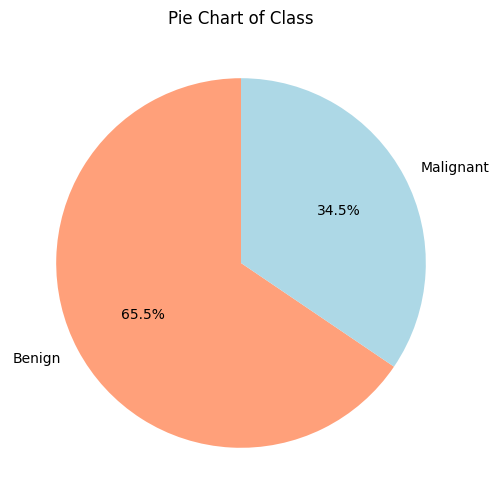

In [164]:
plt.figure(figsize=(10, 6))
df['Class'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=["lightsalmon",'lightblue'], labels=['Benign', 'Malignant'])
plt.title('Pie Chart of Class')
plt.ylabel('')
plt.show()

There are around 65% benign cases and around 35% malignant classes. This is around a 2:1 distribution. I am using the quality criteria sensitivity, so it is not the biggest problem that the classes are a little imbalanced.
The variables are all already floats or integers which is good.

## Task 4- EDA and Preprocessing

Bring the dataset into the form that you need for the experiments.
* • Explore the data and conduct necessary transformations.
* • Visualize or summarize aspects of the dataset (statistics, ranges, distributions, . . . ).
* • If necessary, use different means of preprocessing until the dataset is suitable.
* • If you change data, do not forget to present and summarize relevant properties and distributions
of the result.

In [165]:
df.describe()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
count,699.000000,699.000000,699.000000,699.000000,699.000000,683.000000,699.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.544656,3.437768,2.866953,1.589413,2.689557
std,2.815741,3.051459,2.971913,2.855379,2.214300,3.643857,2.438364,3.053634,1.715078,0.951273
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [166]:
X.isna().sum()

Clump_thickness                 0
Uniformity_of_cell_size         0
Uniformity_of_cell_shape        0
Marginal_adhesion               0
Single_epithelial_cell_size     0
Bare_nuclei                    16
Bland_chromatin                 0
Normal_nucleoli                 0
Mitoses                         0
dtype: int64

Just the bare nuclei variable has missing variables. But also just 16. I will take care of that further down. 

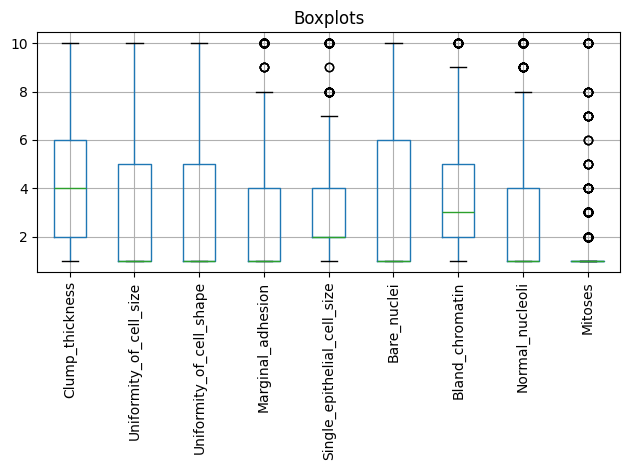

In [167]:
X.boxplot(rot=90)
plt.title("Boxplots")
plt.tight_layout()
plt.show()

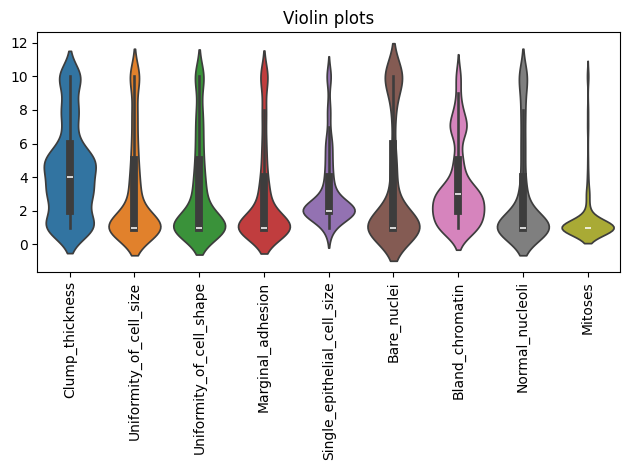

In [168]:
sns.violinplot(data=X)
plt.xticks(rotation=90)
plt.title("Violin plots")
plt.tight_layout()
plt.show()

The boxplot and the violin plot show that there are some variances in the variables. Especially for bare nuclei, bland chromatin and clump thickness there are higher variances.

Text(0.5, 1.0, 'Correlation Heatmap')

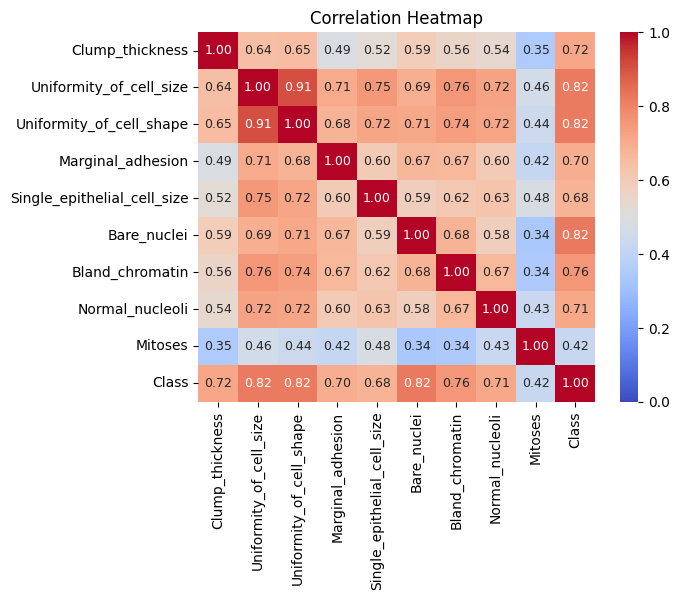

In [169]:
sns.heatmap(df.corr(), annot=True,vmin=0, vmax=1,
annot_kws={"size": 9},
fmt=".2f",cmap="coolwarm")
plt.title("Correlation Heatmap")

Most variables are high correlated. The only variable that isn't highly correlated is mitoses. Because it is also the one that is lowest correlated to class, I expect it to be one of the least important features.

In [170]:
df.groupby("Class").mean()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
Class,,,,,,,,,
2,2.956332,1.325328,1.443231,1.364629,2.120087,1.346847,2.100437,1.290393,1.063319
4,7.195021,6.572614,6.560166,5.547718,5.298755,7.627615,5.979253,5.863071,2.589212


It is visible that divided by the 2 classes, there are very different means for each variable. 

The classes are 2 for benign, 4 for malignant. For better understanding I will change benign to 0 and malignant to 1 (so positive is the cancerous one). 
Also I will take care of the 16 missing cases from "bare nuclei" now. Bare nuclei looks in the violin plot like it has as high variance and is also different for benign and malignant cases, so i will use the KNNImputer for missing values. That will not change the mean nor median much (because there are just 16 cases), so I will not recompute .describe for the statistics again.

In [215]:
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, columns=X.columns)

In [172]:
X.isna().sum()

Clump_thickness                0
Uniformity_of_cell_size        0
Uniformity_of_cell_shape       0
Marginal_adhesion              0
Single_epithelial_cell_size    0
Bare_nuclei                    0
Bland_chromatin                0
Normal_nucleoli                0
Mitoses                        0
dtype: int64

In [173]:
y = y.replace({2: 0, 4: 1})
y
df= df["Class"].replace({2: 0, 4: 1})

## Task 5- First Impressions

Determine an appropriate simple baseline 𝐵 (no trained model) for your task.
* • Select two ML algorithms 𝐴1 and 𝐴2 from the lectures (or their regression counterparts) and
use their implementations in scikit-learn.
* • Briefly discuss relevant dataset transformations that have to be used with each of the algorithms.
Apply them in all tasks where necessary and appropriate!
* • In a simple train test split, learn and evaluate the baseline 𝐵 and both algorithms, 𝐴1 and 𝐴2,
in their respective default parametrization. Use the quality measures from Task 1. Present the
results in a table and discuss them.
* • Evaluate the same, this time using a simple (non-nested) cross validation.
* • Present the new results together with the previous ones in a suitable way – select a good
representation that supports the following discussion. Compare and discuss the results. Among
others adress overfitting, quality, and stability of results.

The first algorithm I am choosing is the decision tree. For that the data doesnt have to be standardized or transformed. For the second algorithm I am choosing random forest. For that they also don't have to be transformed.

In [174]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, stratify=y, shuffle=True,  random_state=1)

y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

In [195]:
# BASELINE
baseline = DummyClassifier(strategy="most_frequent", random_state=1)
baseline.fit(X_train, y_train)

y_train_pred_baseline = baseline.predict(X_train)
y_test_pred_baseline = baseline.predict(X_test)

# A1: Decision Tree
dt = DecisionTreeClassifier(criterion="gini", random_state=1)
dt.fit(X_train, y_train)

y_train_pred_dt = dt.predict(X_train)
y_test_pred_dt = dt.predict(X_test)

# A2: Random Forest
rf = RandomForestClassifier(random_state=1)
rf.fit(X_train, y_train)

y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

# RESULTS TABLE
print("RESULTS: TRAIN-TEST SPLIT")
results_tt = pd.DataFrame({
    "Model": ["Baseline", "Decision Tree", "Random Forest"],
    "Sensitivity_Train": [
        round(metrics.recall_score(y_train, y_train_pred_baseline), 5),
        round(metrics.recall_score(y_train, y_train_pred_dt), 5),
        round(metrics.recall_score(y_train, y_train_pred_rf), 5)
    ],
    "Sensitivity_Test": [
        round(metrics.recall_score(y_test, y_test_pred_baseline), 5),
        round(metrics.recall_score(y_test, y_test_pred_dt), 5),
        round(metrics.recall_score(y_test, y_test_pred_rf), 5)
    ],
    "Precision_Train": [
        round(metrics.precision_score(y_train, y_train_pred_baseline, zero_division=0), 5),
        round(metrics.precision_score(y_train, y_train_pred_dt), 5),
        round(metrics.precision_score(y_train, y_train_pred_rf), 5)
    ],
    "Precision_Test": [
        round(metrics.precision_score(y_test, y_test_pred_baseline, zero_division=0), 5),
        round(metrics.precision_score(y_test, y_test_pred_dt), 5),
        round(metrics.precision_score(y_test, y_test_pred_rf), 5)
    ]
})

print(results_tt.to_string(index=False))

RESULTS: TRAIN-TEST SPLIT
        Model  Sensitivity_Train  Sensitivity_Test  Precision_Train  Precision_Test
     Baseline                0.0           0.00000              0.0         0.00000
Decision Tree                1.0           0.90722              1.0         0.95652
Random Forest                1.0           0.94845              1.0         0.95833


As expected, the baseline has a sensitivity and precision of 0. That is because the model always predicts benign. 
The first algorithm, the decision tree has a sensitivity of 0.907. That means ca. 91 % of cancer cases are found. From the predicted cancer cases , 95.6 % are correct. The problem here is that the sensitiviy for the train set is 1. So there seems to be a strong overfitting, because the gap is nearly 10% between the train and test set. 
The random forest seems to perform better. The sensitivity which is the more important criteria is better with 0.948. There is still a gap between the test sensitivity of 1. But the gap isn't as big. The precision from random forest is a little better than the one from decision tree with 0.958. 


In [217]:
print("Results: Cross Validation")

# Baseline
cv_baseline_sens = cross_val_score(baseline, X_train, y_train, cv=10, scoring="recall")
cv_baseline_prec = cross_val_score(baseline, X_train, y_train, cv=10, 
                                    scoring=metrics.make_scorer(metrics.precision_score, zero_division=0))

# Decision Tree
cv_dt_sens = cross_val_score(DecisionTreeClassifier(criterion="gini", random_state=1),
                             X_train, y_train, cv=10, scoring="recall")
cv_dt_prec = cross_val_score(DecisionTreeClassifier(criterion="gini", random_state=1),
                             X_train, y_train, cv=10, scoring="precision")

# Random Forest
cv_rf_sens = cross_val_score(RandomForestClassifier(random_state=1),
                             X_train, y_train, cv=10, scoring="recall")
cv_rf_prec = cross_val_score(RandomForestClassifier(random_state=1),
                             X_train, y_train, cv=10, scoring="precision")

results_cv = pd.DataFrame({
    "Model": ["Baseline", "Decision Tree", "Random Forest"],
    "Sensitivity_Mean": [
        round(cv_baseline_sens.mean(), 5),
        round(cv_dt_sens.mean(), 5),
        round(cv_rf_sens.mean(), 5)
    ],
    "Sensitivity_Std": [
        round(cv_baseline_sens.std(), 5),
        round(cv_dt_sens.std(), 5),
        round(cv_rf_sens.std(), 5)
    ],
    "Precision_Mean": [
        round(cv_baseline_prec.mean(), 5),
        round(cv_dt_prec.mean(), 5),
        round(cv_rf_prec.mean(), 5)
    ],
    "Precision_Std": [
        round(cv_baseline_prec.std(), 5),
        round(cv_dt_prec.std(), 5),
        round(cv_rf_prec.std(), 5)
    ]
})

print(results_cv.to_string(index=False))


Results: Cross Validation
        Model  Sensitivity_Mean  Sensitivity_Std  Precision_Mean  Precision_Std
     Baseline           0.00000          0.00000         0.00000        0.00000
Decision Tree           0.87571          0.11514         0.93018        0.06096
Random Forest           0.95762          0.04711         0.94276        0.04302


In the cross validation, still as expected, the baseline has a sensitivity and precision of 0. That is because the model always predicts benign. 
The first algorithm, the decision tree has a sensitivity of 0.876. That means ca. 87.6% of cancer cases are found. From the predicted cancer cases , 93 % are correct. So the sensitivity and the precision are lower now.
The random forest seems to perform better here. The sensitivity which is the more important criteria is better with 0.958. The precision from random forest is a little better than the one from decision tree with 0.943.  The Standard deviation of sensitivity of the Random Forest is acceptable with 0.047 and low which points to stable results, but the Standard deviation of the decision tree with 0.12 is high, which points to unstable results. 
 

In [218]:
# COMBINED COMPARISON
print("Train-Test-Split vs Cross Validation")
comparison = pd.DataFrame({
    "Model": ["Baseline", "Decision Tree", "Random Forest"],
    "Sensitivity_Test": results_tt["Sensitivity_Test"],
    "Sensitivity_CV": results_cv["Sensitivity_Mean"],
    "Precision_Test": results_tt["Precision_Test"],
    "Precision_CV": results_cv["Precision_Mean"]
})
print(comparison.to_string(index=False))

Train-Test-Split vs Cross Validation
        Model  Sensitivity_Test  Sensitivity_CV  Precision_Test  Precision_CV
     Baseline           0.00000         0.00000         0.00000       0.00000
Decision Tree           0.90722         0.87571         0.95652       0.93018
Random Forest           0.94845         0.95762         0.95833       0.94276


All in all i would say that the Random Forest is the better algorithm. It has a higher precision and higher sensitivity for the train test split and the cv. While the precision in the simple train test split is better than in the cross validation, the sensitivity from the random forest cross validation is better than the random forest train test split. And that was the most important criteria.
All together you can say that Random Forest consistently outperforms Decision Tree across all metrics and both evaluation methods.

## Task 6 – Hyperparameter Optimization – Nested Cross Validation

Setup a proper nested cross validation experiment to assess and compare the performance of the two
algorithms and the baseline (𝐴1, 𝐴2, and 𝐵 as chosen in Task 5).
* • For each of the two ML algorithms 𝐴1 and 𝐴2, create a reasonable hyperparameter grid.
* • Use those grids in a nested cross validation to evaluate algorithms in their optimal hyperpara-
meter configurations.
* – For the outer cross validation, reuse the splits from Task 5.
* – Inside the cross validation, use pipeline objects that include preprocessing steps and
predictor.
* • Compare your final performance estimates to the previous impressions from Task 5.
* • Discuss your results and express a recommendation with regard to the choice of model. Pick
one model (algorithm with selected hyperparameters) as the final model 𝑀 for the task.

In [178]:
# Global Config 
NUM_TRIALS = 10 
NUM_INNER_REPEATS=10
NUM_INNER_SPLITS=10
NUM_OUTER_SPLITS=10

In [179]:
# Hyperparameter Grids
decision_tree_grid = {
    "estimator__criterion": ["gini", "entropy"], 
    "estimator__max_depth": [5, 10, 15, 20, 30]
}

random_forest_grid = {
    "estimator__n_estimators": [50, 100, 200],
    "estimator__max_depth": [5, 10, 15, 20, 30],
    "estimator__min_samples_split": [2, 5, 10]
}

baseline_grid = {
    "estimator__strategy": ["most_frequent"]
}


In [180]:
def get_pipe(estimator):
    """
    Create a pipeline with estimator.
    """
    return Pipeline([
        ("estimator", estimator)
    ])

In [181]:
def nested_cv(estimator, grid, features, targets, estimator_name):
    """
    Run nested cross-validation with GridSearch hyperparameter tuning.
    
    Returns:
    sensitivities: ndarray
        Sensitivity (recall) values
    precisions: ndarray
        Precision values
    fit_times: ndarray
        Training time per fold
    test_times: ndarray
        Prediction time per fold
    """
    
    start = time.time()
    sensitivities = np.zeros((NUM_TRIALS, NUM_OUTER_SPLITS))
    precisions = np.zeros((NUM_TRIALS, NUM_OUTER_SPLITS))
    fit_times = np.zeros((NUM_TRIALS, NUM_OUTER_SPLITS))
    test_times = np.zeros((NUM_TRIALS, NUM_OUTER_SPLITS))
    
    for i in range(NUM_TRIALS):
        print(f"Running Trial {i} for {estimator_name} at {time.time()-start:.2f}s")
        
        # Create fresh pipeline
        pipe = get_pipe(estimator)
        
        # Inner CV: hyperparameter tuning
        inner_cv = RepeatedStratifiedKFold(
            n_splits=NUM_INNER_SPLITS, 
            n_repeats=NUM_INNER_REPEATS, 
            random_state=i
        )
        
        # Outer CV: evaluation of tuned model
        outer_cv = StratifiedKFold(
            n_splits=NUM_OUTER_SPLITS, 
            shuffle=True, 
            random_state=i
        )
        
        # GridSearchCV for hyperparameter tuning
        clf = GridSearchCV(
            estimator=pipe,
            param_grid=grid,
            cv=inner_cv, 
            scoring="recall",
            n_jobs=-1,
            refit="recall"
        )
        
        # Cross-validate on outer CV
        cv_result = cross_validate(
            clf,
            X=features,
            y=targets,
            cv=outer_cv,
            scoring=("recall", "precision"),
            n_jobs=-1
        )
        
        sensitivities[i] = cv_result["test_recall"]
        precisions[i] = cv_result["test_precision"]
        fit_times[i] = cv_result["fit_time"]
        test_times[i] = cv_result["score_time"]
    
    print(f"Total time for {estimator_name}: {(time.time()-start):.2f} sec.\n")
    return sensitivities, precisions, fit_times, test_times

In [182]:
def add_result(results, name, sensitivities, precisions, fit_times, test_times):
    """Add results to dataframe"""
    row = {
        "name": name,
        "sensitivity_mean": sensitivities.mean(),
        "sensitivity_std": sensitivities.std(),
        "sensitivity_min": sensitivities.min(), 
        "sensitivity_max": sensitivities.max(), 
        "precision_mean": precisions.mean(),
        "precision_std": precisions.std(),
        "precision_min": precisions.min(), 
        "precision_max": precisions.max(), 
        "fit_time": fit_times.mean(),
        "test_time": test_times.mean()
    }
    return pd.concat([results, pd.DataFrame([row])], ignore_index=True)

In [183]:
results = pd.DataFrame()

In [184]:

# Baseline
print("BASELINE: Most Frequent Class")

baseline = DummyClassifier(strategy="most_frequent", random_state=1)
sens_b, prec_b, fit_time_b, test_time_b = nested_cv(baseline, baseline_grid, X, y, "Baseline")
results = add_result(results, "Baseline", sens_b, prec_b, fit_time_b, test_time_b)


BASELINE: Most Frequent Class
Running Trial 0 for Baseline at 0.00s
Running Trial 1 for Baseline at 7.19s
Running Trial 2 for Baseline at 9.25s
Running Trial 3 for Baseline at 10.69s
Running Trial 4 for Baseline at 11.83s
Running Trial 5 for Baseline at 12.91s
Running Trial 6 for Baseline at 14.01s
Running Trial 7 for Baseline at 15.20s
Running Trial 8 for Baseline at 16.40s
Running Trial 9 for Baseline at 17.73s
Total time for Baseline: 19.24 sec.



In [185]:
# Decision Tree

print("ALGORITHM A1: Decision Tree")

dt = DecisionTreeClassifier(random_state=1)
sens_dt, prec_dt, fit_time_dt, test_time_dt = nested_cv(dt, decision_tree_grid, X, y, "Decision Tree")
results = add_result(results, "Decision Tree", sens_dt, prec_dt, fit_time_dt, test_time_dt)

ALGORITHM A1: Decision Tree
Running Trial 0 for Decision Tree at 0.00s
Running Trial 1 for Decision Tree at 17.78s
Running Trial 2 for Decision Tree at 33.85s
Running Trial 3 for Decision Tree at 50.15s
Running Trial 4 for Decision Tree at 66.14s
Running Trial 5 for Decision Tree at 83.28s
Running Trial 6 for Decision Tree at 100.71s
Running Trial 7 for Decision Tree at 117.71s
Running Trial 8 for Decision Tree at 133.89s
Running Trial 9 for Decision Tree at 166.50s
Total time for Decision Tree: 197.12 sec.



In [186]:
# Random Forest
print("ALGORITHM A2: Random Forest")

rf = RandomForestClassifier(random_state=1)
sens_rf, prec_rf, fit_time_rf, test_time_rf = nested_cv(rf, random_forest_grid, X, y, "Random Forest")
results = add_result(results, "Random Forest", sens_rf, prec_rf, fit_time_rf, test_time_rf)

ALGORITHM A2: Random Forest
Running Trial 0 for Random Forest at 0.00s
Running Trial 1 for Random Forest at 1670.36s
Running Trial 2 for Random Forest at 3457.56s
Running Trial 3 for Random Forest at 4849.23s
Running Trial 4 for Random Forest at 6223.93s
Running Trial 5 for Random Forest at 8083.06s
Running Trial 6 for Random Forest at 9619.47s
Running Trial 7 for Random Forest at 11216.94s
Running Trial 8 for Random Forest at 13108.03s
Running Trial 9 for Random Forest at 14746.90s
Total time for Random Forest: 16522.01 sec.



In [192]:
#results

print("NESTED CROSS-VALIDATION RESULTS")

print(results.to_string(index=False))

# Sort by sensitivity (primary metric for cancer detection)

print("RESULTS SORTED BY SENSITIVITY")

results_sorted = results.sort_values(by="sensitivity_mean", ascending=False)
print(results_sorted.to_string(index=False))


NESTED CROSS-VALIDATION RESULTS
         name  sensitivity_mean  sensitivity_std  sensitivity_min  sensitivity_max  precision_mean  precision_std  precision_min  precision_max    fit_time  test_time
     Baseline          0.000000         0.000000         0.000000              0.0        0.000000       0.000000       0.000000            0.0    1.105995   0.012821
Decision Tree          0.918300         0.057092         0.750000              1.0        0.917850       0.055047       0.774194            1.0   19.100037   0.021231
Random Forest          0.963417         0.040935         0.833333              1.0        0.946897       0.040701       0.857143            1.0 1641.065744   0.096951
RESULTS SORTED BY SENSITIVITY
         name  sensitivity_mean  sensitivity_std  sensitivity_min  sensitivity_max  precision_mean  precision_std  precision_min  precision_max    fit_time  test_time
Random Forest          0.963417         0.040935         0.833333              1.0        0.946897     

Despite its much longer training time, I would choose the Random Forest model as the final model because it offers clearly better clinical performance.

Most importantly, it achieves a much higher sensitivity (96.3% vs. 91.8%), meaning it detects about 4–5 additional cancer cases per 100 patients. In a cancer screening context, each missed case can have severe or fatal consequences, making this improvement clinically meaningful.

The Random Forest model is also more stable, with lower performance variability (std = 0.041 vs. 0.057), indicating more reliable and reproducible results. Even in the worst-case scenario, its sensitivity remains higher (83.3% vs. 75%), providing greater safety. 

Random Forest has also better precision 94.7% compared to 91.8% from decision tree. So when Random Forest predicts cancer, it's correct nearly 3% more often than Decision Tree.

Although training takes much longer for the Random forest, this is acceptable. Prediction time is fast with 0.097 seconds, making the model suitable for real-time.

In conclusion, for cancer detection, accuracy and reliability are clearly more important than training speed, so I choose Random Forest as the preferred final model.

In [193]:
def train_prod_model(estimator, grid, features, targets, estimator_name):
    """Train final model using best hyperparameters on all data"""
    pipe = get_pipe(estimator)
    cv = RepeatedStratifiedKFold(
        n_splits=NUM_INNER_SPLITS, 
        n_repeats=NUM_INNER_REPEATS, 
        random_state=1
    )
    clf = GridSearchCV(
        estimator=pipe, 
        param_grid=grid, 
        cv=cv, 
        n_jobs=-1, 
        scoring="recall"
    )
    clf.fit(features, targets)
    
    print(f"\n{estimator_name} - Best Parameters:")
    print(clf.best_params_)
    print(f"Best CV Recall Score: {clf.best_score_:.5f}")
    
    return clf

In [189]:
final_rf = train_prod_model(
    RandomForestClassifier(random_state=1), 
    random_forest_grid, 
    X, y, 
    "Random Forest"
)



Random Forest - Best Parameters:
{'estimator__max_depth': 5, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 200}
Best CV Recall Score: 0.96508


The best Hyperparameters for my Random Forest are max depth 5, min sample split 2 and n_estimators 200, making it my final Model. 

## Task 7 – Feature Importance / Feature Ablation Study

Familiarize yourself with the idea of feature importance through feature permutation.
*  Analyze and discuss the most important features according to feature permutation with the
final model 𝑀 (the result of Task 6).
*  Plot the feature importances in a suitable diagram. Analyze and discuss the diagram.
*  Ablation Study:
* – Pick the two least important features 𝐹1 and 𝐹2 (according to the above results).
* – Reuse the outer cross-validation from Task 6 to train and evaluate the final model 𝑀 with
different feature sets (no further hyperparameter optimization).
* – For that purpose, add another preprocessing step to the pipeline that removes one or more
features from the data.
* – Train and evaluate 𝑀 using your dataset in the cross-validation while excluding 𝐹1 from
the data.
* – Train and evaluate 𝑀 using your dataset in the cross-validation while excluding 𝐹2 from
the data.
* – Train and evaluate 𝑀 using your dataset in the cross-validation while excluding 𝐹1 and
𝐹2 from the data simultaneously.
* – Present and discuss your results. Particularly compare to the impressions from the feature
importance study and explain.

In [191]:
from sklearn.inspection import permutation_importance

In [198]:
model_m = final_rf.best_estimator_

In [199]:
perm_importance = permutation_importance(
    model_m, 
    X, 
    y,
    n_repeats=10,
    random_state=1,
    scoring="recall"
)

In [201]:
importance=perm_importance.importances_mean
importance_std=perm_importance.importances_std

Permutation Importance


<function matplotlib.pyplot.show(close=None, block=None)>

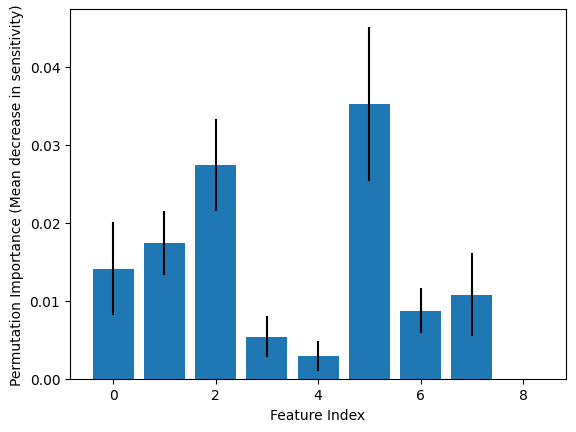

In [ ]:
print("Permutation Importance")
plt.bar(np.arange(len(importance)),importance, yerr=importance_std)
plt.xlabel("Feature Index")

plt.ylabel("Permutation Importance (Mean decrease in sensitivity)")
plt.show()

The most important feature is number 5, "Bare_nuclei". When shuffled, sensitivity on average drops by  3.5%. Also number 2, Uniformity_of_cell_shape seems to be important. When shuffled, sensitivity drops by ca. 2.7%. 
Earlier in the analysis we could see that many features are highly correlated. So that's why all feature importance is just around 0.01 to 0.035. Because if one feature would drop out, the model could compensate with using the correlated features. 
So even a of 3.5% from just losing one feature (the Bare Nuclei) points to a meaningful feature. 

Feature Number 8 is "Mitoses" is F1. It has no importance for the sensitivity.
The other low importance feature F2 is number 4, Single_epithelial_cell_size, it has just a very low importance. When shuffeld the sensitivity drops on average by ca 0.3%. 

In [ ]:
class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None):
        self.columns = columns if columns is not None else []

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=self.columns, errors="ignore")

In [209]:
rf_best = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=2,
    random_state=1
)

In [210]:
NUM_OUTER_SPLITS = 10
outer_cv = StratifiedKFold(n_splits=NUM_OUTER_SPLITS, shuffle=True, random_state=1)

In [211]:
F1 = "Mitoses"                       
F2 = "Single_epithelial_cell_size" 

In [212]:
def eval_feature_set(drop_cols, name):

    print(f"Feature set: {name}")


    pipe = Pipeline([
        ("drop", DropColumns(columns=drop_cols)),
        ("rf", rf_best)
    ])
    cv_res = cross_validate(
        pipe,
        X=X,          
        y=y,
        cv=outer_cv,
        scoring=("recall", "precision"),
        n_jobs=-1
    )

    sens_mean = cv_res["test_recall"].mean()
    sens_std  = cv_res["test_recall"].std()
    prec_mean = cv_res["test_precision"].mean()
    prec_std  = cv_res["test_precision"].std()

    print(f"Sensitivity: {sens_mean:.5f} (± {sens_std:.5f})")
    print(f"Precision:   {prec_mean:.5f} (± {prec_std:.5f})")
    
    return {
        "Feature_Set": name,
        "Dropped": ", ".join(drop_cols) if drop_cols else "None",
        "Sensitivity_Mean": sens_mean,
        "Sensitivity_Std": sens_std,
        "Precision_Mean": prec_mean,
        "Precision_Std": prec_std
    }

In [ ]:
results = []

# drop F1 
results.append(eval_feature_set([F1], f"Without F1 ({F1})"))

# drop F2
results.append(eval_feature_set([F2], f"Without F2 ({F2})"))

# drop F1 and F2
results.append(eval_feature_set([F1, F2], f"Without F1 and F2 ({F1}, {F2})"))

Feature set: Without F1 (Mitoses)
Sensitivity: 0.96683 (± 0.03114)
Precision:   0.94705 (± 0.05286)
Feature set: Without F2 (Single_epithelial_cell_size)
Sensitivity: 0.96267 (± 0.02915)
Precision:   0.94984 (± 0.04651)
Feature set: Without F1 and F2 (Mitoses, Single_epithelial_cell_size)
Sensitivity: 0.96683 (± 0.03114)
Precision:   0.94701 (± 0.05264)


When removing the two least important features (Mitoses and Single_epithelial_cell_size), the sensitivity and precision of the final Random Forest model remain nearly the same (sensitivity around 0.96–0.97, precision ca. 0.95). Removing F1 and F2 seems to not hurt the model at all, on the contrary for removing F1 it even gets slightly better, but just on the 3rd decimal number. That is within the Standard deviation of the cases before, so I think the little higher without F1 is not statistically significant. Otherwise it could be because some "noise" was removed with removing F1. 
All in all this confirms the permutation importance analysis, that F1 and F2 have very low importance and their removal has nearly no impact on model performance.

## Task 8 – Conclusions and Future Work

1. Summarize and interpret the achieved results.

In summary, the optimized Random Forest model achieves a sensitivity of about 96% and a precision of about 95% in nested cross-validation. So it provides both, a high cancer detection and a low rate of false alarms. Compared to the Decision Tree baseline, it detects roughly 4–5 additional cancers per 100 patients, has a higher precision and shows lower variance across folds, making it more reliable and stable. 

The feature importance analyses shows that some features like Bare_nuclei and uniformity of cell shape hold a higher predictive power than others, while the 2 least important features can be removed without harming the performance of the model. 


2. Explain the generated value within the context of your task.

The original goal from Task 1 was, To support breast cancer diagnosis by classifying cytology samples as benign vs malignant, most importantly, to detect as many malignant cases as possible. For this reason sensitivity was used as the primary metric, and precision as a secondary metric to keep false alarms low. In the clinical context, missing a cancer case would be the biggest problem. 
A sensitivity of around 96% means that the model can catch the majority of the malignant tumors in this dataset. This could support doctors by finding suspicious cases that deserve closer inspection or additional tests. 
At the same time, a precision of around 95% means that most positive predictions are actually cancer, which helps to avoid too many unnecessary biopsies or panic for patients. 
Even though the numbers are good, the model should definitely not replace a pathologist, because still these 4% of missed cases would be too high. 
But it could work as a decision‑support tool that gives a second opinion based on the cytology scores that are already collected.

The feature importance analysis also showed, that bare nuclei is a strong predictor, so it suggest the doctors to take a strong look at this variable and maybe not so much attention to the mitoses. 

3. Propose ideas for future work (a short sketch or enumeration of ideas is sufficient, no further
experiments). The ideas should not be too general (e.g., “try further algorithms”) but be specific
to the project (e.g., “try Algorithm X, as because of Property Y, it might work specifically well
on this dataset”).

 One next step could be to use class weights, so that false negatives are penalized even more strongly. This could maybe slightly increase sensitivity. 
 Since all features are ordinal scores from 1 to 10, it would also be interesting to test other models that take that into account, for example the Logisitc Regression which works well with ordinal scores.  
 Also with bagging and boosting different classifiers could be combined into a stronger one.
 I think it is also important to test the models again on another data set with maybe more cases, because this came just from one doctor (so one source). 
 Also the maybe the least important feature can be removed next time, so the computation could be faster.

4. Critically reflect and assess the usability of the applied methodology in your context (as
described in Task 1). Explain limitations and pitfalls. What could or even should have been done
differently? In hindsight, were the goals realistic? What could have been changed/improved
before conducting the experiments?

I think the general approach was suitable for the question, but there are of course limitations. 
The dataset is relatively small for machine learning and also comes from just one source, so the performance of the model is probably more optimistic than compared to a scenario in any other hospital. 
Also the nested cross‑validation setup was very slow, especially for the Random Forest.
Another configuration would probably have given nearly as good conclusions with much less computation.
Overall, however, the goals of the project were realistic for this dataset. I could find a good model, with a high sensitivity and the importance analysis showed that some variables were not as important and therefor can be neglected.